In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )
    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x.view(-1, 784)
        return self.model(x)

generator = Generator()
discriminator = Discriminator()

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 888kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.47MB/s]


In [10]:
criterion = nn.BCELoss()  # Binary Cross-Entropy - measures how wrong a "real vs fake" guess is

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

noise_dim = 100

In [11]:
epochs = 20

for epoch in range(epochs):
    for real_images, _ in train_loader:
        batch_size = real_images.size(0)

        # Labels: real images should be judged as "1" (real), fake as "0" (fake)
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # ---- Train Discriminator ----
        optimizer_D.zero_grad()

        # Show it real images, it should say "close to 1"
        output_real = discriminator(real_images)
        loss_real = criterion(output_real, real_labels)

        # Show it fake images (from Generator), it should say "close to 0"
        noise = torch.randn(batch_size, noise_dim)
        fake_images = generator(noise)
        output_fake = discriminator(fake_images.detach())  # detach = don't train Generator here
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        optimizer_G.zero_grad()

        # Generator wants Discriminator to say "1" (real) on its fake images
        output = discriminator(fake_images)
        loss_G = criterion(output, real_labels)  # trick: use real_labels here on purpose

        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch [1/20] | D Loss: 0.0140 | G Loss: 6.3899
Epoch [2/20] | D Loss: 0.1518 | G Loss: 3.7083
Epoch [3/20] | D Loss: 0.1087 | G Loss: 5.7318
Epoch [4/20] | D Loss: 0.0575 | G Loss: 5.8322
Epoch [5/20] | D Loss: 0.0676 | G Loss: 6.5545
Epoch [6/20] | D Loss: 0.0641 | G Loss: 6.3663
Epoch [7/20] | D Loss: 0.1615 | G Loss: 6.3749
Epoch [8/20] | D Loss: 0.1765 | G Loss: 4.7708
Epoch [9/20] | D Loss: 0.3822 | G Loss: 4.8826
Epoch [10/20] | D Loss: 0.0846 | G Loss: 6.0823
Epoch [11/20] | D Loss: 0.2542 | G Loss: 4.5219
Epoch [12/20] | D Loss: 0.1991 | G Loss: 4.0297
Epoch [13/20] | D Loss: 0.3478 | G Loss: 3.3739
Epoch [14/20] | D Loss: 0.5118 | G Loss: 3.3711
Epoch [15/20] | D Loss: 0.3225 | G Loss: 3.4334
Epoch [16/20] | D Loss: 0.4786 | G Loss: 2.6095
Epoch [17/20] | D Loss: 0.5061 | G Loss: 4.1100
Epoch [18/20] | D Loss: 0.6990 | G Loss: 2.9953
Epoch [19/20] | D Loss: 0.3731 | G Loss: 2.2601
Epoch [20/20] | D Loss: 0.2624 | G Loss: 2.8143


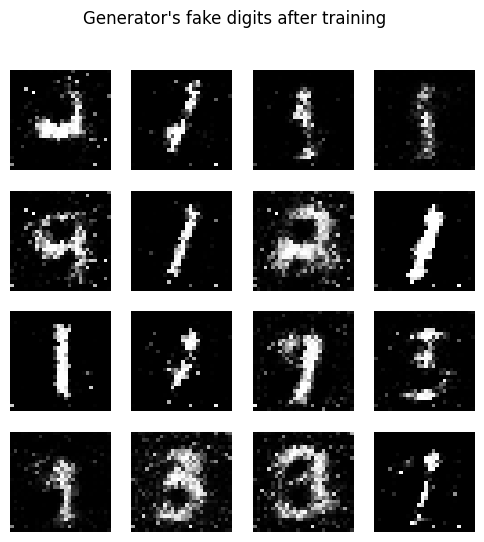

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

In [12]:
generator.eval()
with torch.no_grad():
    noise = torch.randn(16, noise_dim)
    fake_images = generator(noise)

fig, axes = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    img = fake_images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')
plt.suptitle("Generator's fake digits after training")
plt.show()
generator.train()

Downloading: "https://github.com/facebookresearch/pytorch_GAN_zoo/zipball/hub" to /root/.cache/torch/hub/hub.zip
Downloading: "https://dl.fbaipublicfiles.com/gan_zoo/DCGAN_fashionGen-1d67302.pth" to /root/.cache/torch/hub/checkpoints/DCGAN_fashionGen-1d67302.pth


100%|██████████| 39.7M/39.7M [00:01<00:00, 41.5MB/s]


Average network found !


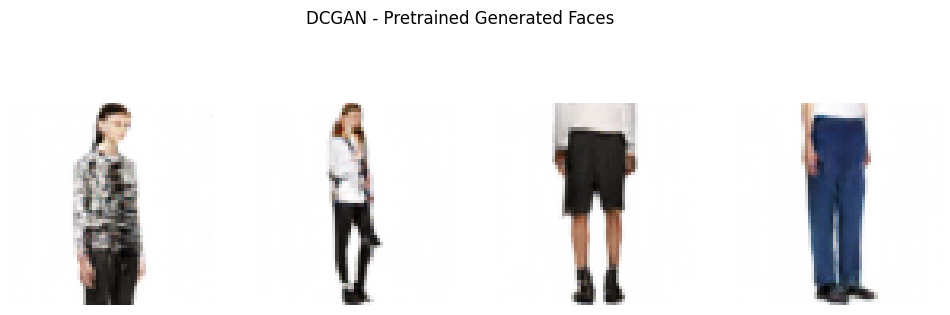

In [13]:
import torch
import matplotlib.pyplot as plt

# loading pretrained model of clothes
use_gpu = torch.cuda.is_available()
model = torch.hub.load('facebookresearch/pytorch_GAN_zoo:hub', 'DCGAN', pretrained=True, useGPU=use_gpu)

# fake img generation
num_images = 4
noise, _ = model.buildNoiseData(num_images)
with torch.no_grad():
    generated_images = model.test(noise)

# Display
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i, ax in enumerate(axes):
    img = generated_images[i].permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())  # normalize for display
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("DCGAN - Pretrained Generated Faces")
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

num_classes = 10
noise_dim = 100

class ConditionalGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        # Label ko bhi ek "embedding" (numbers) mein convert karte hain
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(noise_dim + num_classes, 256),   # noise + label dono ek saath
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )
    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([noise, label_input], dim=1)   # noise aur label ko jodo
        return self.model(x).view(-1, 1, 28, 28)

class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 512),   # image + label dono ek saath
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_input = self.label_emb(labels)
        x = torch.cat([img_flat, label_input], dim=1)
        return self.model(x)

generator = ConditionalGenerator()
discriminator = ConditionalDiscriminator()
print("Models created")

Models created


In [17]:
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

In [18]:
#training loop
epochs = 20

for epoch in range(epochs):
    for real_images, real_class_labels in train_loader:
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # ---- Train Discriminator ----
        optimizer_D.zero_grad()

        # Real images, REAL digit labels (0-9)
        output_real = discriminator(real_images, real_class_labels)
        loss_real = criterion(output_real, real_labels)

        # Fake images - random noise AND random digit label
        noise = torch.randn(batch_size, noise_dim)
        random_digit_labels = torch.randint(0, num_classes, (batch_size,))
        fake_images = generator(noise, random_digit_labels)
        output_fake = discriminator(fake_images.detach(), random_digit_labels)
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        optimizer_G.zero_grad()
        output = discriminator(fake_images, random_digit_labels)
        loss_G = criterion(output, real_labels)
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch [1/20] | D Loss: 0.2916 | G Loss: 5.1927
Epoch [2/20] | D Loss: 0.3223 | G Loss: 3.1931
Epoch [3/20] | D Loss: 0.0433 | G Loss: 6.7306
Epoch [4/20] | D Loss: 0.0446 | G Loss: 5.3558
Epoch [5/20] | D Loss: 0.1397 | G Loss: 4.0712
Epoch [6/20] | D Loss: 0.2727 | G Loss: 6.3433
Epoch [7/20] | D Loss: 0.1834 | G Loss: 6.9912
Epoch [8/20] | D Loss: 0.2716 | G Loss: 4.8186
Epoch [9/20] | D Loss: 0.4117 | G Loss: 4.3491
Epoch [10/20] | D Loss: 0.2718 | G Loss: 5.2925
Epoch [11/20] | D Loss: 0.1913 | G Loss: 4.7021
Epoch [12/20] | D Loss: 0.2245 | G Loss: 4.2929
Epoch [13/20] | D Loss: 0.4775 | G Loss: 5.8444
Epoch [14/20] | D Loss: 0.1542 | G Loss: 6.3238
Epoch [15/20] | D Loss: 0.1873 | G Loss: 5.3145
Epoch [16/20] | D Loss: 0.3030 | G Loss: 3.6839
Epoch [17/20] | D Loss: 0.2553 | G Loss: 4.3589
Epoch [18/20] | D Loss: 0.2320 | G Loss: 3.4352
Epoch [19/20] | D Loss: 0.2966 | G Loss: 4.5325
Epoch [20/20] | D Loss: 0.1703 | G Loss: 5.4303


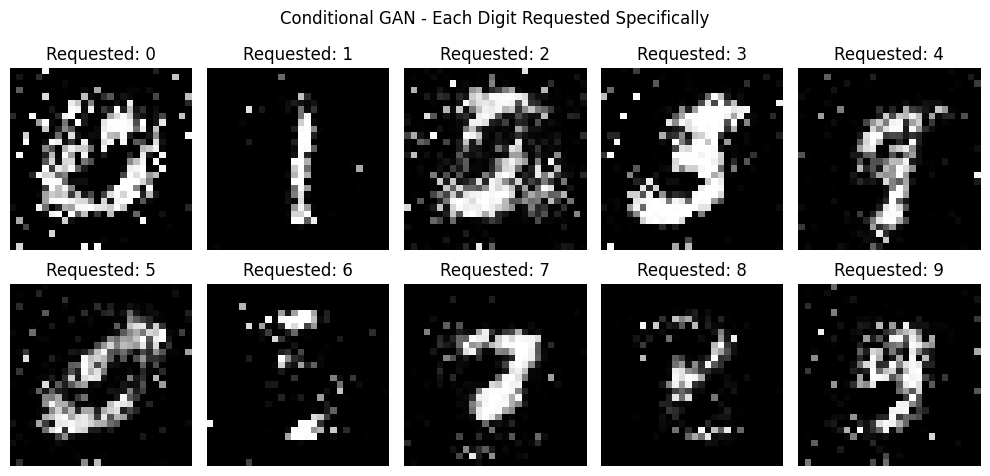

ConditionalGenerator(
  (label_emb): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

In [19]:
generator.eval()

# generate 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
with torch.no_grad():
    for digit in range(10):
        noise = torch.randn(1, noise_dim)
        label = torch.tensor([digit])
        fake_image = generator(noise, label)

        ax = axes[digit // 5, digit % 5]
        ax.imshow(fake_image.squeeze().numpy(), cmap='gray')
        ax.set_title(f"Requested: {digit}")
        ax.axis('off')

plt.suptitle("Conditional GAN - Each Digit Requested Specifically")
plt.tight_layout()
plt.show()

generator.train()